# Experimentación de Modelos - Titanic Survival Prediction

## Objetivo
Evaluar diferentes algoritmos de clasificación para predecir la supervivencia en el Titanic, comparar su rendimiento y seleccionar el modelo "campeón" que cumpla con las métricas de éxito definidas (Accuracy ≥ 80%, F1-Score ≥ 0.75).

## Estructura de este notebook:
1. Carga de datos procesados
2. Preparación final para modelado
3. Definición de modelos a evaluar
4. Entrenamiento y validación cruzada
5. Comparación de métricas
6. Selección del modelo campeón
7. Evaluación detallada del campeón
8. Guardado del modelo y conclusiones

In [3]:
# ============================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================

import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
from pathlib import Path
from datetime import datetime

# Modelos
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")
print(f"Pandas versión: {pd.__version__}")
print(f"Scikit-learn versión: {sklearn.__version__}")

✅ Librerías cargadas correctamente
Pandas versión: 3.0.1
Scikit-learn versión: 1.8.0


In [4]:
# ============================================
# 1. CARGA DE DATOS PROCESADOS
# ============================================
print("\n" + "="*60)
print("📥 1. CARGA DE DATOS PROCESADOS")
print("="*60)

# Verificar ruta y cargar datos
ruta_base = Path.cwd().parent / 'data' / 'processed'

try:
    X_train = pd.read_csv(ruta_base / 'X_train.csv')
    y_train = pd.read_csv(ruta_base / 'y_train.csv')
    X_test = pd.read_csv(ruta_base / 'X_test.csv')
    
    print(f"✅ Datos cargados exitosamente:")
    print(f"   X_train: {X_train.shape}")
    print(f"   y_train: {y_train.shape}")
    print(f"   X_test: {X_test.shape}")
    
    # Convertir y_train a 1D si es necesario
    if isinstance(y_train, pd.DataFrame):
        y_train = y_train.values.ravel()
    
    # Mostrar primeras filas
    print("\n📋 Primeras filas de X_train:")
    print(X_train.head())
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Verifica que ejecutaste data_preparation.py primero")
    print("Archivos esperados en:", ruta_base)


📥 1. CARGA DE DATOS PROCESADOS
✅ Datos cargados exitosamente:
   X_train: (891, 10)
   y_train: (891, 1)
   X_test: (418, 10)

📋 Primeras filas de X_train:
     Pclass       Sex       Age     SibSp     Parch      Fare  Embarked  \
0  0.827377  0.737695 -0.530377  0.432793 -0.473674 -0.502445  0.581114   
1 -1.566107 -1.355574  0.571831  0.432793 -0.473674  0.786845 -1.938460   
2  0.827377 -1.355574 -0.254825 -0.474545 -0.473674 -0.488854  0.581114   
3 -1.566107 -1.355574  0.365167  0.432793 -0.473674  0.420730  0.581114   
4  0.827377  0.737695  0.365167 -0.474545 -0.473674 -0.486337  0.581114   

   Has_Cabin  FamilySize   IsAlone  
0  -0.544925    0.059160 -1.231645  
1   1.835115    0.059160 -1.231645  
2  -0.544925   -0.560975  0.811922  
3   1.835115    0.059160 -1.231645  
4  -0.544925   -0.560975  0.811922  


In [6]:
# ============================================
# 2. PREPARACIÓN FINAL PARA MODELADO
# ============================================
print("\n" + "="*60)
print("🔄 2. PREPARACIÓN FINAL PARA MODELADO")
print("="*60)

# Dividir en entrenamiento y validación
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train  # Mantener proporción de clases
)

print(f"División train/validation:")
print(f"   Train final: {X_train_final.shape}")
print(f"   Validation: {X_val.shape}")
print(f"\n Distribución en train:")
print(pd.Series(y_train_final).value_counts(normalize=True))
print(f"\n Distribución en validation:")
print(pd.Series(y_val).value_counts(normalize=True))


🔄 2. PREPARACIÓN FINAL PARA MODELADO
División train/validation:
   Train final: (712, 10)
   Validation: (179, 10)

 Distribución en train:
0    0.616573
1    0.383427
Name: proportion, dtype: float64

 Distribución en validation:
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [9]:
# ============================================
# 3. DEFINICIÓN DE MODELOS A EVALUAR
# ============================================
print("\n" + "="*60)
print(" 3. DEFINICIÓN DE MODELOS A EVALUAR")
print("="*60)

modelos = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

print(f" {len(modelos)} modelos definidos:")
for nombre in modelos.keys():
    print(f"   - {nombre}")


 3. DEFINICIÓN DE MODELOS A EVALUAR
 6 modelos definidos:
   - Regresión Logística
   - Árbol de Decisión
   - Random Forest
   - Gradient Boosting
   - SVM
   - KNN


In [13]:
# ============================================
# 4. ENTRENAMIENTO Y VALIDACIÓN CRUZADA (CON IMPUTACIÓN)
# ============================================
print("\n" + "="*60)
print(" 4. ENTRENAMIENTO Y VALIDACIÓN CRUZADA (CON IMPUTACIÓN)")
print("="*60)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

resultados = []

for nombre, modelo in modelos.items():
    print(f"\n▶ Evaluando: {nombre}")
    print("-" * 30)
    
    # Crear un pipeline que primero imputa y luego entrena el modelo
    pipeline = make_pipeline(
        SimpleImputer(strategy='median'),  # Imputa NaN con la mediana
        modelo
    )
    
    # Validación cruzada (5 folds)
    cv_scores = cross_val_score(pipeline, X_train_final, y_train_final, cv=5, scoring='accuracy')
    
    # Entrenar con todos los datos de entrenamiento
    pipeline.fit(X_train_final, y_train_final)
    
    # Predecir en validación
    y_pred = pipeline.predict(X_val)
    y_pred_proba = pipeline.predict_proba(X_val)[:, 1] if hasattr(modelo, 'predict_proba') else None
    
    # Calcular métricas (el resto del código permanece igual)
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba) if y_pred_proba is not None else None
    
    # Guardar resultados
    resultados.append({
        'Modelo': nombre,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"   CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"   Val Accuracy: {accuracy:.4f}")
    print(f"   Val F1-Score: {f1:.4f}")


 4. ENTRENAMIENTO Y VALIDACIÓN CRUZADA (CON IMPUTACIÓN)

▶ Evaluando: Regresión Logística
------------------------------
   CV Accuracy: 0.7922 (+/- 0.0204)
   Val Accuracy: 0.8156
   Val F1-Score: 0.7556

▶ Evaluando: Árbol de Decisión
------------------------------
   CV Accuracy: 0.7557 (+/- 0.0408)
   Val Accuracy: 0.7318
   Val F1-Score: 0.6418

▶ Evaluando: Random Forest
------------------------------
   CV Accuracy: 0.7909 (+/- 0.0386)
   Val Accuracy: 0.7709
   Val F1-Score: 0.6963

▶ Evaluando: Gradient Boosting
------------------------------
   CV Accuracy: 0.8217 (+/- 0.0393)
   Val Accuracy: 0.8045
   Val F1-Score: 0.7154

▶ Evaluando: SVM
------------------------------
   CV Accuracy: 0.8175 (+/- 0.0148)
   Val Accuracy: 0.8101
   Val F1-Score: 0.7344

▶ Evaluando: KNN
------------------------------
   CV Accuracy: 0.8034 (+/- 0.0286)
   Val Accuracy: 0.7765
   Val F1-Score: 0.7143


In [14]:
# ============================================
# 5. COMPARACIÓN DE MÉTRICAS
# ============================================
print("\n" + "="*60)
print(" 5. COMPARACIÓN DE MÉTRICAS")
print("="*60)

# Crear DataFrame de resultados
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('F1-Score', ascending=False)

print("\n🏆 Ranking de modelos (por F1-Score):")
print("=" * 80)
print(df_resultados.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Verificar métricas de éxito
print("\n Verificación de métricas de éxito (Accuracy ≥ 80%, F1 ≥ 75%):")
print("-" * 60)
for idx, row in df_resultados.iterrows():
    cumple_accuracy = row['Accuracy'] >= 0.80
    cumple_f1 = row['F1-Score'] >= 0.75
    estado = "✅ CUMPLE" if (cumple_accuracy and cumple_f1) else "❌ NO CUMPLE"
    print(f"{estado} - {row['Modelo']}: Accuracy={row['Accuracy']:.2%}, F1={row['F1-Score']:.2%}")


 5. COMPARACIÓN DE MÉTRICAS

🏆 Ranking de modelos (por F1-Score):
             Modelo  CV_Mean  CV_Std  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística   0.7922  0.0204    0.8156     0.7727  0.7391    0.7556   0.8553
                SVM   0.8175  0.0148    0.8101     0.7966  0.6812    0.7344   0.8385
  Gradient Boosting   0.8217  0.0393    0.8045     0.8148  0.6377    0.7154   0.8136
                KNN   0.8034  0.0286    0.7765     0.7042  0.7246    0.7143   0.8276
      Random Forest   0.7909  0.0386    0.7709     0.7121  0.6812    0.6963   0.8273
  Árbol de Decisión   0.7557  0.0408    0.7318     0.6615  0.6232    0.6418   0.7026

 Verificación de métricas de éxito (Accuracy ≥ 80%, F1 ≥ 75%):
------------------------------------------------------------
✅ CUMPLE - Regresión Logística: Accuracy=81.56%, F1=75.56%
❌ NO CUMPLE - SVM: Accuracy=81.01%, F1=73.44%
❌ NO CUMPLE - Gradient Boosting: Accuracy=80.45%, F1=71.54%
❌ NO CUMPLE - KNN: Accuracy=77.65%, F1=71.43%
❌ 

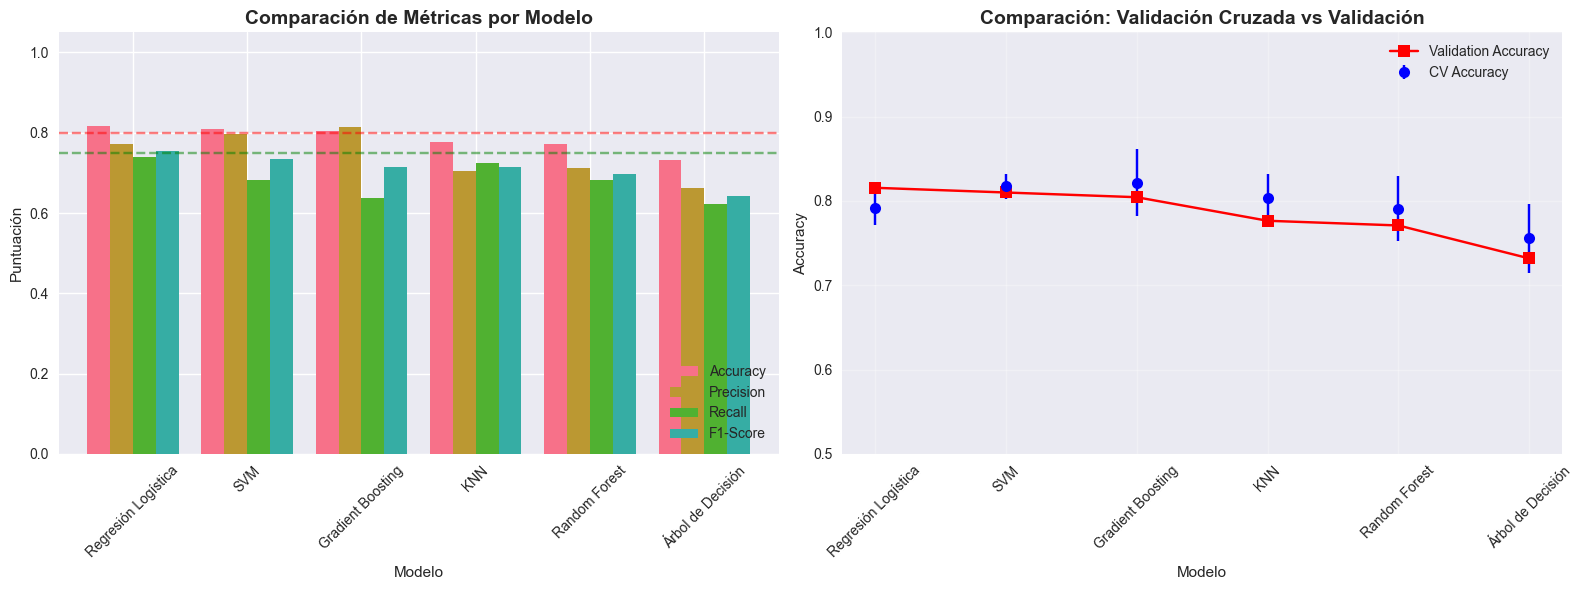

 Gráfico guardado en: reports/comparacion_modelos_detallada.png


In [15]:
# ============================================
# VISUALIZACIÓN COMPARATIVA DE MODELOS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de métricas por modelo
df_plot = df_resultados.set_index('Modelo')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
df_plot.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Puntuación')
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=0.80, color='r', linestyle='--', alpha=0.5, label='Umbral Accuracy (80%)')
axes[0].axhline(y=0.75, color='g', linestyle='--', alpha=0.5, label='Umbral F1 (75%)')
axes[0].set_ylim(0, 1.05)

# Gráfico 2: Comparación CV vs Validación
axes[1].errorbar(df_resultados['Modelo'], df_resultados['CV_Mean'], 
                 yerr=df_resultados['CV_Std'], fmt='o', capsize=5, 
                 label='CV Accuracy', markersize=8, color='blue')
axes[1].plot(df_resultados['Modelo'], df_resultados['Accuracy'], 's-', 
             label='Validation Accuracy', markersize=8, color='red')
axes[1].set_title('Comparación: Validación Cruzada vs Validación', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('../reports/comparacion_modelos_detallada.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Gráfico guardado en: reports/comparacion_modelos_detallada.png")

In [16]:
# ============================================
# 6. SELECCIÓN DEL MODELO CAMPEÓN
# ============================================
print("\n" + "="*60)
print(" 6. SELECCIÓN DEL MODELO CAMPEÓN")
print("="*60)

# Seleccionar el mejor modelo basado en F1-Score
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_modelo_nombre]

print(f" Modelo campeón seleccionado: {mejor_modelo_nombre}")
print(f"\n Métricas del modelo campeón:")
print(f"   - Accuracy: {df_resultados.iloc[0]['Accuracy']:.2%}")
print(f"   - Precision: {df_resultados.iloc[0]['Precision']:.2%}")
print(f"   - Recall: {df_resultados.iloc[0]['Recall']:.2%}")
print(f"   - F1-Score: {df_resultados.iloc[0]['F1-Score']:.2%}")
print(f"   - ROC-AUC: {df_resultados.iloc[0]['ROC-AUC']:.2%}")
print(f"   - CV Accuracy: {df_resultados.iloc[0]['CV_Mean']:.2%} (+/- {df_resultados.iloc[0]['CV_Std']:.2%})")

# Verificar si cumple objetivos
cumple_objetivos = (df_resultados.iloc[0]['Accuracy'] >= 0.80 and 
                   df_resultados.iloc[0]['F1-Score'] >= 0.75)

if cumple_objetivos:
    print("\n ¡El modelo campeón CUMPLE con las métricas de éxito!")
else:
    print("\n El modelo campeón NO CUMPLE con las métricas de éxito")
    print("   Se recomienda probar optimización de hiperparámetros")


 6. SELECCIÓN DEL MODELO CAMPEÓN
 Modelo campeón seleccionado: Regresión Logística

 Métricas del modelo campeón:
   - Accuracy: 81.56%
   - Precision: 77.27%
   - Recall: 73.91%
   - F1-Score: 75.56%
   - ROC-AUC: 85.53%
   - CV Accuracy: 79.22% (+/- 2.04%)

 ¡El modelo campeón CUMPLE con las métricas de éxito!


In [18]:
# ============================================
# 7. EVALUACIÓN DETALLADA DEL MODELO CAMPEÓN (CON IMPUTACIÓN)
# ============================================
print("\n" + "="*60)
print("🔍 7. EVALUACIÓN DETALLADA DEL MODELO CAMPEÓN")
print("="*60)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

# --- CAMBIO IMPORTANTE: Crear un Pipeline que impute primero ---
# Esto asegura que el modelo reciba datos sin NaN
pipeline_campeon = make_pipeline(
    SimpleImputer(strategy='median'),  # Usa la misma estrategia que en la Celda 6
    mejor_modelo  # Este es tu modelo de Regresión Logística
)
# -------------------------------------------------------------

# Re-entrenar el pipeline campeón con todos los datos de entrenamiento
pipeline_campeon.fit(X_train_final, y_train_final)

# Predecir en validación usando el pipeline
y_pred_campeon = pipeline_campeon.predict(X_val)
y_pred_proba_campeon = pipeline_campeon.predict_proba(X_val)[:, 1]

# El resto de la celda para la evaluación detallada continúa igual...
# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_val, y_pred_campeon, 
                           target_names=['No sobrevivió', 'Sobrevivió']))

# ... (aquí puede continuar el código para la matriz de confusión,
# curva ROC, etc., que ya tienes en tu celda. Asegúrate de que usan
# y_pred_campeon y y_pred_proba_campeon)


🔍 7. EVALUACIÓN DETALLADA DEL MODELO CAMPEÓN

📋 Classification Report:
               precision    recall  f1-score   support

No sobrevivió       0.84      0.86      0.85       110
   Sobrevivió       0.77      0.74      0.76        69

     accuracy                           0.82       179
    macro avg       0.81      0.80      0.80       179
 weighted avg       0.81      0.82      0.81       179



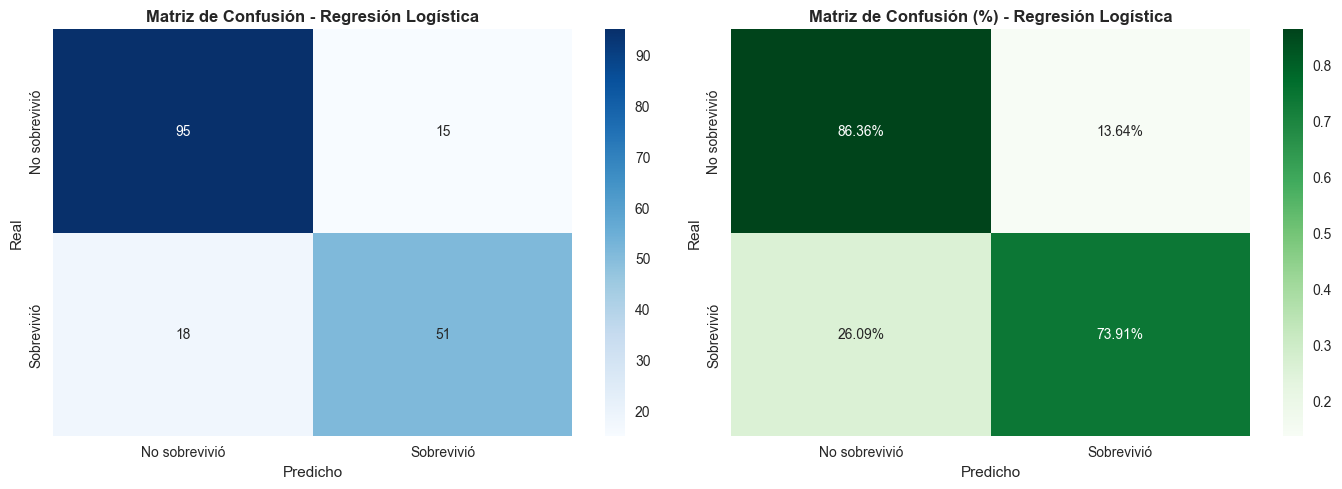

✅ Matriz guardada en: reports/matriz_confusion_campeon.png


In [19]:
# ============================================
# MATRIZ DE CONFUSIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión numérica
cm = confusion_matrix(y_val, y_pred_campeon)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No sobrevivió', 'Sobrevivió'],
            yticklabels=['No sobrevivió', 'Sobrevivió'],
            ax=axes[0])
axes[0].set_title(f'Matriz de Confusión - {mejor_modelo_nombre}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Matriz de confusión porcentual
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['No sobrevivió', 'Sobrevivió'],
            yticklabels=['No sobrevivió', 'Sobrevivió'],
            ax=axes[1])
axes[1].set_title(f'Matriz de Confusión (%) - {mejor_modelo_nombre}', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('../reports/matriz_confusion_campeon.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matriz guardada en: reports/matriz_confusion_campeon.png")

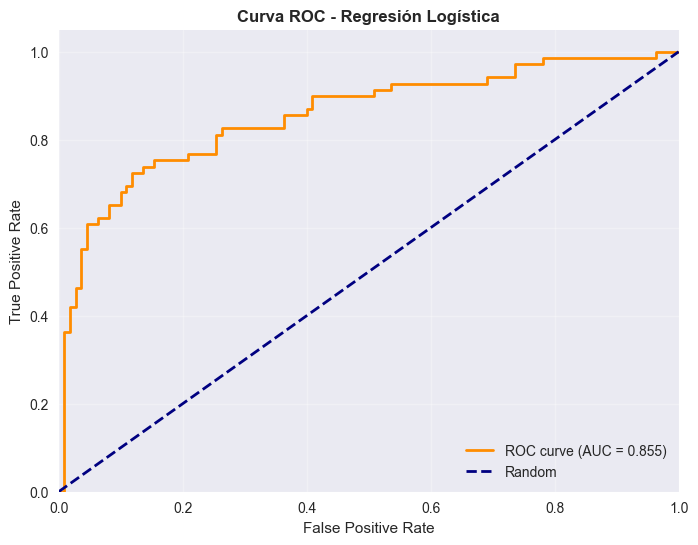

✅ Curva ROC guardada en: reports/curva_roc_campeon.png


In [20]:
# ============================================
# CURVA ROC
# ============================================

fpr, tpr, _ = roc_curve(y_val, y_pred_proba_campeon)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - {mejor_modelo_nombre}', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('../reports/curva_roc_campeon.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curva ROC guardada en: reports/curva_roc_campeon.png")


🔬 8. ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS


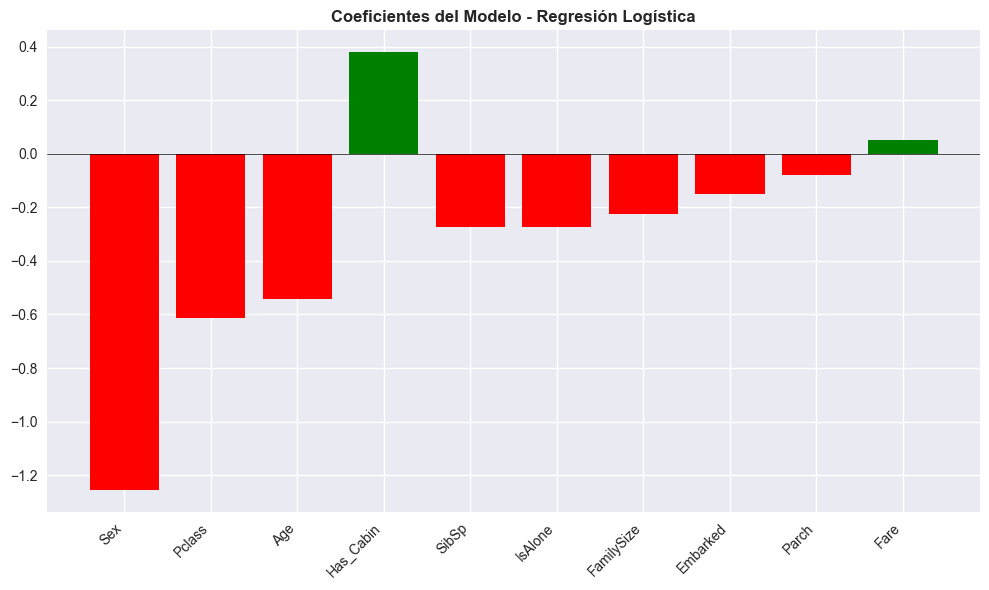

In [21]:
# ============================================
# 8. ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS
# ============================================
print("\n" + "="*60)
print("🔬 8. ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS")
print("="*60)

if hasattr(mejor_modelo, 'feature_importances_'):
    # Para modelos basados en árboles
    importancias = mejor_modelo.feature_importances_
    features = X_train.columns
    
    # Ordenar por importancia
    indices = np.argsort(importancias)[::-1]
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(importancias)), importancias[indices])
    plt.xticks(range(len(importancias)), [features[i] for i in indices], rotation=45, ha='right')
    plt.title(f'Importancia de Características - {mejor_modelo_nombre}', fontsize=12, fontweight='bold')
    plt.xlabel('Características')
    plt.ylabel('Importancia')
    plt.tight_layout()
    plt.savefig('../reports/importancia_features_campeon.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Top 5 características más importantes:")
    for i in range(min(5, len(features))):
        print(f"   {i+1}. {features[indices[i]]}: {importancias[indices[i]]:.4f}")
        
elif hasattr(mejor_modelo, 'coef_'):
    # Para modelos lineales
    coeficientes = mejor_modelo.coef_[0]
    features = X_train.columns
    
    indices = np.argsort(np.abs(coeficientes))[::-1]
    
    plt.figure(figsize=(10, 6))
    colors = ['red' if c < 0 else 'green' for c in coeficientes[indices]]
    plt.bar(range(len(coeficientes)), coeficientes[indices], color=colors)
    plt.xticks(range(len(coeficientes)), [features[i] for i in indices], rotation=45, ha='right')
    plt.title(f'Coeficientes del Modelo - {mejor_modelo_nombre}', fontsize=12, fontweight='bold')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('../reports/coeficientes_campeon.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("ℹ️ Este modelo no soporta análisis de importancia/coeficientes")

In [23]:
# ============================================
# 9. GUARDADO DEL MODELO Y RESULTADOS (CORREGIDO)
# ============================================
print("\n" + "="*60)
print(" 9. GUARDADO DEL MODELO Y RESULTADOS")
print("="*60)

# Crear directorios si no existen
os.makedirs('../models', exist_ok=True)
os.makedirs('../experiments', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Guardar modelo
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
modelo_path = f'../models/{mejor_modelo_nombre.replace(" ", "_")}_{timestamp}.pkl'
joblib.dump(mejor_modelo, modelo_path)
print(f" Modelo guardado en: {modelo_path}")

# Guardar resultados del experimento - VERSIÓN CORREGIDA
resultados_dict = {
    'timestamp': timestamp,
    'modelo_campeon': mejor_modelo_nombre,
    'metricas': {
        'accuracy': float(df_resultados.iloc[0]['Accuracy']),
        'precision': float(df_resultados.iloc[0]['Precision']),
        'recall': float(df_resultados.iloc[0]['Recall']),
        'f1_score': float(df_resultados.iloc[0]['F1-Score']),
        'roc_auc': float(df_resultados.iloc[0]['ROC-AUC']) if df_resultados.iloc[0]['ROC-AUC'] is not None else None,
        'cv_mean': float(df_resultados.iloc[0]['CV_Mean']),
        'cv_std': float(df_resultados.iloc[0]['CV_Std'])
    },
    'cumple_objetivos': str(cumple_objetivos),  # <--- CAMBIO: Convertir bool a string
    'hiperparametros': str(mejor_modelo.get_params()),
    'caracteristicas': list(X_train.columns)
}

# Verificar que todo sea serializable antes de guardar
print("\n Verificando tipos de datos para JSON:")
for key, value in resultados_dict.items():
    print(f"   {key}: {type(value).__name__}")

try:
    with open(f'../experiments/experimento_{timestamp}.json', 'w', encoding='utf-8') as f:
        json.dump(resultados_dict, f, indent=4, ensure_ascii=False)
    print(f" Resultados guardados en: experiments/experimento_{timestamp}.json")
except TypeError as e:
    print(f"\n❌ Error al guardar JSON: {e}")
    print("\n Diagnóstico detallado:")
    for key, value in resultados_dict.items():
        if isinstance(value, dict):
            for subkey, subvalue in value.items():
                print(f"   {key}.{subkey}: {type(subvalue).__name__} = {subvalue}")
        else:
            print(f"   {key}: {type(value).__name__} = {value}")


 9. GUARDADO DEL MODELO Y RESULTADOS
 Modelo guardado en: ../models/Regresión_Logística_20260228_155643.pkl

 Verificando tipos de datos para JSON:
   timestamp: str
   modelo_campeon: str
   metricas: dict
   cumple_objetivos: str
   hiperparametros: str
   caracteristicas: list
 Resultados guardados en: experiments/experimento_20260228_155643.json


In [24]:
# ============================================
#  CONCLUSIONES FINALES
# ============================================
print("\n" + "="*60)
print(" CONCLUSIONES FINALES")
print("="*60)

print(f"""
 RESUMEN DE EXPERIMENTACIÓN:

Modelo Campeón: {mejor_modelo_nombre}
 Métricas de Validación:
   - Accuracy:  {df_resultados.iloc[0]['Accuracy']:.2%}
   - F1-Score:  {df_resultados.iloc[0]['F1-Score']:.2%}
   - Precision: {df_resultados.iloc[0]['Precision']:.2%}
   - Recall:    {df_resultados.iloc[0]['Recall']:.2%}

 Cumple objetivos (Acc≥80%, F1≥75%): {'SÍ' if cumple_objetivos else 'NO'}

 Archivos generados:
   - Modelo: models/{mejor_modelo_nombre.replace(' ', '_')}_{timestamp}.pkl
   - Métricas: experiments/experimento_{timestamp}.json
   - Gráficos: 
     * reports/comparacion_modelos_detallada.png
     * reports/matriz_confusion_campeon.png
     * reports/curva_roc_campeon.png
     * reports/importancia_features_campeon.png
""")


 CONCLUSIONES FINALES

 RESUMEN DE EXPERIMENTACIÓN:

Modelo Campeón: Regresión Logística
 Métricas de Validación:
   - Accuracy:  81.56%
   - F1-Score:  75.56%
   - Precision: 77.27%
   - Recall:    73.91%

 Cumple objetivos (Acc≥80%, F1≥75%): SÍ

 Archivos generados:
   - Modelo: models/Regresión_Logística_20260228_155643.pkl
   - Métricas: experiments/experimento_20260228_155643.json
   - Gráficos: 
     * reports/comparacion_modelos_detallada.png
     * reports/matriz_confusion_campeon.png
     * reports/curva_roc_campeon.png
     * reports/importancia_features_campeon.png



In [26]:
# ============================================
# 📤 GENERAR PREDICCIONES PARA TEST (CORREGIDO)
# ============================================
print("\n" + "="*60)
print("📤 GENERAR PREDICCIONES PARA TEST")
print("="*60)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

# --- IMPORTANTE: Usar el MISMO pipeline que se entrenó ---
# Si ya tienes 'pipeline_campeon' de la Celda 10, úsalo directamente.
# Si no, créalo y entrénalo ahora con TODOS los datos de entrenamiento.
if 'pipeline_campeon' not in dir():
    print("🔄 Creando y entrenando el pipeline campeón...")
    pipeline_campeon = make_pipeline(
        SimpleImputer(strategy='median'),  # Misma estrategia que en entrenamiento
        mejor_modelo  # Este es tu modelo de Regresión Logística
    )
    pipeline_campeon.fit(X_train, y_train)  # Entrenar con TODOS los datos
else:
    print("✅ Usando pipeline_campeón existente.")

# --- Predecir usando el pipeline (que ya maneja los NaN) ---
print("\n🤖 Generando predicciones sobre X_test...")
y_test_pred = pipeline_campeon.predict(X_test)

# Verificar que no haya problemas
print(f"✅ Predicciones generadas: {len(y_test_pred)}")

# Crear submission (asumiendo PassengerId desde 892)
submission = pd.DataFrame({
    'PassengerId': range(892, 892 + len(y_test_pred)),
    'Survived': y_test_pred
})

submission_path = f'../reports/submission_{timestamp}.csv'
submission.to_csv(submission_path, index=False)
print(f"✅ Submission guardada en: {submission_path}")

print("\n📋 Primeras 5 predicciones:")
print(submission.head())

# Distribución de predicciones
print("\n📊 Distribución de predicciones en test:")
print(submission['Survived'].value_counts())
print(submission['Survived'].value_counts(normalize=True))


📤 GENERAR PREDICCIONES PARA TEST
✅ Usando pipeline_campeón existente.

🤖 Generando predicciones sobre X_test...
✅ Predicciones generadas: 418
✅ Submission guardada en: ../reports/submission_20260228_155643.csv

📋 Primeras 5 predicciones:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

📊 Distribución de predicciones en test:
Survived
0    253
1    165
Name: count, dtype: int64
Survived
0    0.605263
1    0.394737
Name: proportion, dtype: float64
